In [1]:
#%pip install qiskit-aer


In [2]:

import numpy as np
import qiskit
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import SamplerV2


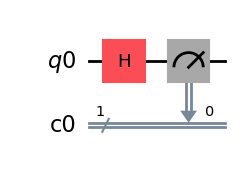

In [3]:
qr = QuantumRegister(1)
cr = ClassicalRegister(1)
qc = QuantumCircuit(qr, cr)
qc.h(qr[0])
qc.measure(qr, cr)

qc.draw('mpl')

In [4]:
Simulator = AerSimulator()
result = Simulator.run(qc, memory=True).result()
result_shots = result.get_counts(qc)
print(result_shots)

{'1': 505, '0': 519}


## Generate random numbers using AerSimulator()

In [5]:
n_bits = 8
n_rand_nums = 10
results_dict = {}
results_dict['str'] = []
results_dict['int'] = []

Simulator = AerSimulator()

for _ in range(n_rand_nums):
    result = Simulator.run(qc, shots=n_bits, memory=True).result()
    result_shots = [(ele[2]) for ele in result.data().get('memory')]
    result_str = ''.join(result_shots)
    results_dict['str'].append(result_str)
    results_dict['int'].append(int(result_str, 2))

#results_n = list(zip(results_dict['str'], results_dict['int']))
#print(results_n)
print('\n generated random numbers: ', results_dict['int'])


 generated random numbers:  [72, 131, 129, 110, 106, 233, 177, 179, 2, 139]


## Generate random numbers using Sampler. AerSimulator() as backend

In [6]:
n_bits = 8
n_rand_nums = 10

results_dict = {}
results_dict['str'] = []
results_dict['int'] = []

backend = AerSimulator()
Sampler = SamplerV2(mode=backend)
for _ in range(n_rand_nums):
    result = Sampler.run([qc], shots=n_bits).result()
    result_shots = result[0].data.c0.to_bool_array()
    result_char = [str(int(ele[0])) for ele in result_shots]
    result_str = ''.join(result_char)
    result_int = int(result_str, 2)
    results_dict['str'].append(result_str)
    results_dict['int'].append(result_int)

results_n = list(zip(results_dict['str'], results_dict['int']))
print(results_n)
print('\n generated random numbers: ', results_dict['int'])


[('01111100', 124), ('01000110', 70), ('00000000', 0), ('00111000', 56), ('11001101', 205), ('10101011', 171), ('00100110', 38), ('00000110', 6), ('01000111', 71), ('01100000', 96)]

 generated random numbers:  [124, 70, 0, 56, 205, 171, 38, 6, 71, 96]


# Pseudo-random number generator in Python

In [9]:
import random

n_bits = 8
n_rand_nums = 10

rand_nums = [random.randint(0, 2**n_bits - 1) for _ in range(n_rand_nums)]

print('\n generated random numbers: ', rand_nums)


 generated random numbers:  [156, 209, 68, 113, 103, 130, 161, 135, 185, 111]
